In [1]:
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2
!pip install jiwer
!pip install einops addict easydict

In [2]:
from datasets import load_from_disk, DatasetDict

dataset = load_from_disk(
    "../data/evaluation_results_dataset",
)

/home/p1neapple/miniconda3/envs/nlp_2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from tqdm import tqdm
from jiwer import cer, wer
import torch


def calculate_cer(predictions, references):
    """
    Calculate Character Error Rate (CER) for a list of predictions.
    """
    return cer(references, predictions)


def calculate_wer(predictions, references):
    """
    Calculate Word Error Rate (WER) for a list of predictions.
    """
    return wer(references, predictions)


for data in dataset:
    preds = data["finetuned_prediction"]
    refs = data["text"]

    cer_value = calculate_cer(preds, refs)
    wer_value = calculate_wer(preds, refs)

    print(f"CER: {cer_value:.4f}, WER: {wer_value:.4f}")

CER: 0.7500, WER: 1.0000
CER: 0.0000, WER: 0.0000
CER: 0.3333, WER: 1.0000
CER: 0.0000, WER: 0.0000
CER: 1.0000, WER: 1.0000
CER: 1.0000, WER: 1.0000
CER: 0.7500, WER: 1.0000
CER: 1.0000, WER: 1.0000
CER: 1.0000, WER: 1.0000
CER: 0.8000, WER: 1.0000
CER: 0.8000, WER: 1.0000
CER: 0.0000, WER: 0.0000
CER: 1.0000, WER: 1.0000
CER: 1.0000, WER: 1.0000
CER: 1.0000, WER: 1.0000
CER: 0.3333, WER: 1.0000
CER: 0.3333, WER: 1.0000
CER: 0.0000, WER: 0.0000
CER: 0.3333, WER: 1.0000
CER: 1.0000, WER: 1.0000
CER: 0.2500, WER: 1.0000
CER: 0.3333, WER: 1.0000
CER: 0.2500, WER: 1.0000
CER: 0.6000, WER: 1.0000
CER: 0.6667, WER: 1.0000
CER: 0.0000, WER: 0.0000
CER: 1.0000, WER: 1.0000
CER: 0.2500, WER: 1.0000
CER: 0.8000, WER: 1.0000
CER: 0.0000, WER: 0.0000
CER: 0.0000, WER: 0.0000
CER: 0.0000, WER: 0.0000
CER: 1.3333, WER: 1.0000
CER: 0.0000, WER: 0.0000
CER: 1.0000, WER: 1.0000
CER: 0.6667, WER: 1.0000
CER: 0.6667, WER: 1.0000
CER: 0.3333, WER: 1.0000
CER: 0.6667, WER: 1.0000
CER: 1.0000, WER: 1.0000


In [4]:
dataset[0]

{'image': <PIL.PngImagePlugin.PngImageFile image mode=L size=128x128>,
 'text': 'toàn',
 'baseline_prediction': '\\[\\begin{align*}f_{\\mathbf{pan}}\\end{align*}\\]',
 'finetuned_prediction': 'tạo'}

## Visual Analysis of Results

We will visualize the results to qualitatively compare the Baseline and Finetuned models. We are particularly interested in cases where the Finetuned model performs better than the Baseline.

Random samples comparison:


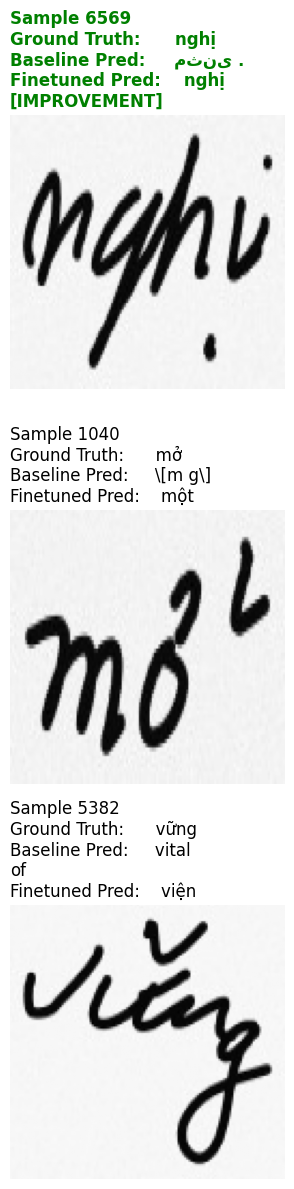

In [5]:
import matplotlib.pyplot as plt
import random


def visualize_comparison(dataset, num_samples=5, random_seed=None):
    if random_seed is not None:
        random.seed(random_seed)

    indices = random.sample(range(len(dataset)), min(num_samples, len(dataset)))

    fig, axes = plt.subplots(num_samples, 1, figsize=(12, 4 * num_samples))
    if num_samples == 1:
        axes = [axes]

    for i, idx in enumerate(indices):
        sample = dataset[idx]
        image = sample["image"]
        ground_truth = sample["text"]
        baseline_pred = sample.get("baseline_prediction", "N/A")
        finetuned_pred = sample.get("finetuned_prediction", "N/A")

        ax = axes[i]
        ax.imshow(image, cmap="gray")
        ax.axis("off")

        title = f"Sample {idx}\n"
        title += f"Ground Truth:      {ground_truth}\n"
        title += f"Baseline Pred:     {baseline_pred}\n"
        title += f"Finetuned Pred:    {finetuned_pred}"

        # Highlight improvement
        if baseline_pred != ground_truth and finetuned_pred == ground_truth:
            title += "\n[IMPROVEMENT]"
            ax.set_title(
                title, loc="left", fontsize=12, color="green", fontweight="bold"
            )
        elif baseline_pred == ground_truth and finetuned_pred != ground_truth:
            title += "\n[REGRESSION]"
            ax.set_title(title, loc="left", fontsize=12, color="red")
        else:
            ax.set_title(title, loc="left", fontsize=12)

    plt.tight_layout()
    plt.show()


# Visualize random samples
print("Random samples comparison:")
visualize_comparison(dataset, num_samples=3)

Found 2937 samples where Finetuned model improved over Baseline (perfect match).

Visualizing improvements:


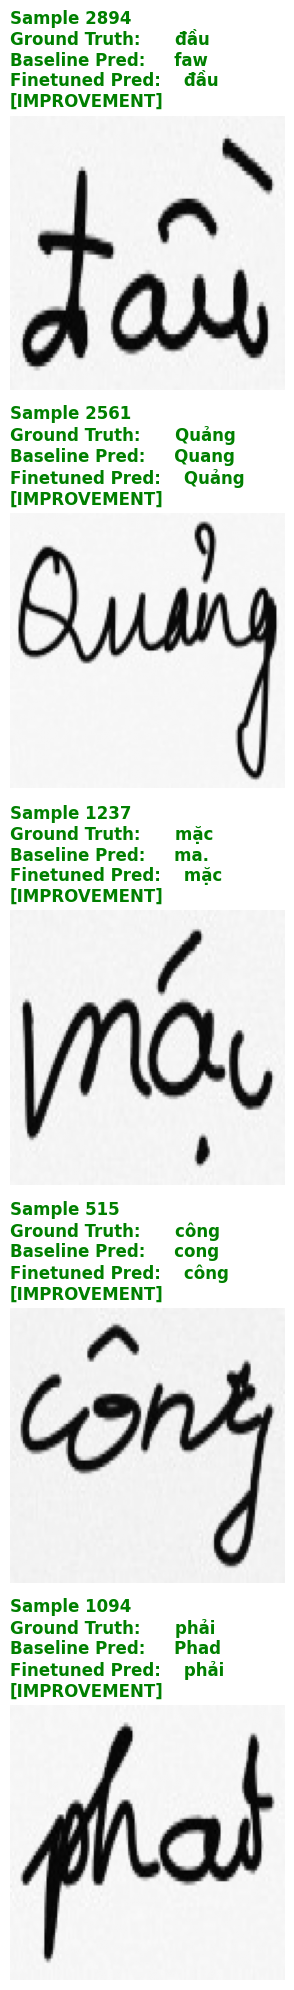

In [6]:
def find_improvements(dataset):
    improvement_indices = []
    for i in range(len(dataset)):
        sample = dataset[i]
        gt = sample["text"]
        base = sample.get("baseline_prediction", "")
        fine = sample.get("finetuned_prediction", "")

        # Simple check: Baseline is wrong, Finetuned is correct
        if base != gt and fine == gt:
            improvement_indices.append(i)

    return improvement_indices


improvement_indices = find_improvements(dataset)
print(
    f"Found {len(improvement_indices)} samples where Finetuned model improved over Baseline (perfect match)."
)

if improvement_indices:
    # Create a subset for visualization
    improved_dataset = dataset.select(improvement_indices)
    print("\nVisualizing improvements:")
    visualize_comparison(improved_dataset, num_samples=5)
else:
    print("No perfect improvements found.")

In [7]:
# Save some good examples for the report
import os

output_dir = "../report/img/results"
os.makedirs(output_dir, exist_ok=True)


def save_comparison_image(dataset, idx, save_path):
    sample = dataset[idx]
    image = sample["image"]
    ground_truth = sample["text"]
    baseline_pred = sample.get("baseline_prediction", "N/A")
    finetuned_pred = sample.get("finetuned_prediction", "N/A")

    plt.figure(figsize=(10, 4))
    plt.imshow(image, cmap="gray")
    plt.axis("off")

    title = f"Ground Truth: {ground_truth}\n"
    title += f"Baseline: {baseline_pred}\n"
    title += f"Finetuned: {finetuned_pred}"

    plt.title(title, loc="left", fontsize=14)
    plt.tight_layout()
    plt.savefig(save_path, bbox_inches="tight", dpi=300)
    plt.close()
    print(f"Saved comparison to {save_path}")


if improvement_indices:
    # Save top 3 improvements
    for i in range(min(3, len(improvement_indices))):
        idx = improvement_indices[i]
        save_path = os.path.join(output_dir, f"improvement_example_{i+1}.png")
        save_comparison_image(dataset, idx, save_path)

Saved comparison to ../report/img/results/improvement_example_1.png
Saved comparison to ../report/img/results/improvement_example_2.png
Saved comparison to ../report/img/results/improvement_example_3.png


Found 65 samples where Finetuned model performed worse than Baseline (regression).

Visualizing regressions:


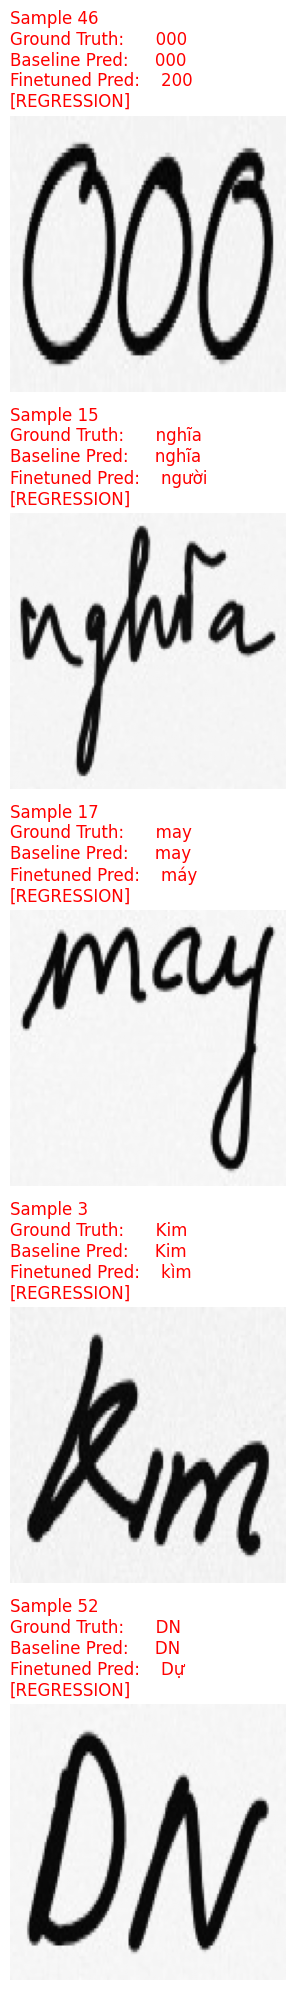

In [8]:
def find_regressions(dataset):
    regression_indices = []
    for i in range(len(dataset)):
        sample = dataset[i]
        gt = sample["text"]
        base = sample.get("baseline_prediction", "")
        fine = sample.get("finetuned_prediction", "")

        # Check: Baseline is correct, Finetuned is wrong
        if base == gt and fine != gt:
            regression_indices.append(i)

    return regression_indices


regression_indices = find_regressions(dataset)
print(
    f"Found {len(regression_indices)} samples where Finetuned model performed worse than Baseline (regression)."
)

if regression_indices:
    # Create a subset for visualization
    regression_dataset = dataset.select(regression_indices)
    print("\nVisualizing regressions:")
    visualize_comparison(regression_dataset, num_samples=5)
else:
    print("No regressions found.")

In [9]:
if regression_indices:
    # Save top 3 regressions
    for i in range(min(3, len(regression_indices))):
        idx = regression_indices[i]
        save_path = os.path.join(output_dir, f"regression_example_{i+1}.png")
        save_comparison_image(dataset, idx, save_path)

Saved comparison to ../report/img/results/regression_example_1.png
Saved comparison to ../report/img/results/regression_example_2.png
Saved comparison to ../report/img/results/regression_example_3.png


In [ ]:
def find_worst_cases(dataset, top_k=5):
    scores = []
    for i in range(len(dataset)):
        sample = dataset[i]
        ref = sample["text"]
        pred = sample.get("finetuned_prediction", "")

        # Calculate CER
        # We use the previously imported cer function
        try:
            score = cer(ref, pred)
        except Exception as e:
            score = 0.0

        scores.append((i, score))

    # Sort descending by error rate
    scores.sort(key=lambda x: x[1], reverse=True)
    return [x[0] for x in scores[:top_k]]
    

worst_indices = find_worst_cases(dataset, top_k=5)
print(f"Found top {len(worst_indices)} worst cases based on CER.")

if worst_indices:
    worst_dataset = dataset.select(worst_indices)
    print("\nVisualizing worst cases (Highest CER):")
    visualize_comparison(worst_dataset, num_samples=len(worst_indices))

Found top 5 worst cases based on CER.

Visualizing worst cases (Highest CER):


/tmp/ipykernel_29222/2981411596.py:43: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


In [11]:
if worst_indices:
    # Save top 3 worst cases
    for i in range(min(3, len(worst_indices))):
        idx = worst_indices[i]
        save_path = os.path.join(output_dir, f"worst_case_example_{i+1}.png")
        save_comparison_image(dataset, idx, save_path)

/tmp/ipykernel_29222/1980698889.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Saved comparison to ../report/img/results/worst_case_example_1.png
Saved comparison to ../report/img/results/worst_case_example_2.png
Saved comparison to ../report/img/results/worst_case_example_3.png
